<a href="https://colab.research.google.com/github/josethomas568/Real-Time-Streaming-Data-Pipeline/blob/main/Spark_Structured_Streaming.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Spark Structured Streaming with NewsAPI & Kafka
~ Jose Thomas

## Pipeline Overview
```
NewsAPI  ──►  Kafka topic1  ──►  PySpark Structured Streaming (NER)  ──►  Kafka topic2  ──►  Matplotlib bar charts  ──►  LLM Enrichment
```


---
## Section 0 — Environment Setup



In [ ]:
# ── Install Python dependencies ──────────────────────────────────────────────
!pip install -q newsapi-python kafka-python pyspark spacy groq
!python -m spacy download en_core_web_sm -q
print("✓ Python dependencies installed")


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 326.1/326.1 kB 5.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 142.3/142.3 kB 5.3 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.8/12.8 MB 69.4 MB/s eta 0:00:00
✔ Download and installation successful
You can now load the package via spacy.load('en_core_web_sm')
⚠ Restart to reload dependencies
If you are in a Jupyter or Colab notebook, you may need to restart Python in
order to load all the package's dependencies. You can do this by selecting the
'Restart kernel' or 'Restart runtime' option.
✓ Python dependencies installed


In [ ]:
# ── Install Java (required by PySpark) ───────────────────────────────────────
!apt-get install -y -q openjdk-17-jdk-headless
import os
os.environ["JAVA_HOME"] = "/usr/lib/jvm/java-17-openjdk-amd64"
!java -version


Reading package lists...
Building dependency tree...
Reading state information...
openjdk-17-jdk-headless is already the newest version (17.0.18+8-1~22.04.1).
0 upgraded, 0 newly installed, 0 to remove and 3 not upgraded.
openjdk version "17.0.18" 2026-01-20
OpenJDK Runtime Environment (build 17.0.18+8-Ubuntu-122.04.1)
OpenJDK 64-Bit Server VM (build 17.0.18+8-Ubuntu-122.04.1, mixed mode, sharing)


In [ ]:
# ── Download Kafka ────────────────────────────────────────────────────────────
import subprocess, os, shutil

KAFKA_VERSION = "3.7.1"
KAFKA_DIR     = f"kafka_2.13-{KAFKA_VERSION}"
KAFKA_TGZ     = f"{KAFKA_DIR}.tgz"
KAFKA_URL     = f"https://archive.apache.org/dist/kafka/{KAFKA_VERSION}/{KAFKA_TGZ}"

if os.path.exists(KAFKA_DIR) and not os.path.exists(f"{KAFKA_DIR}/bin/kafka-storage.sh"):
    shutil.rmtree(KAFKA_DIR)

if not os.path.exists(KAFKA_DIR):
    print("Downloading Kafka…")
    ret = subprocess.run(f"wget -q {KAFKA_URL}", shell=True)
    if ret.returncode != 0:
        raise RuntimeError(f"Download failed: {KAFKA_URL}")
    subprocess.run(f"tar -xzf {KAFKA_TGZ}", shell=True, check=True)
    print(f"✓ Kafka {KAFKA_VERSION} extracted")
else:
    print(f"✓ Kafka {KAFKA_VERSION} already present")


✓ Kafka 3.7.1 extracted


In [ ]:
# ── Start Kafka broker (KRaft mode — no Zookeeper) ───────────────────────────
import subprocess, time

KAFKA_DIR = "kafka_2.13-3.7.1"

cluster_id = subprocess.check_output(
    f"bash {KAFKA_DIR}/bin/kafka-storage.sh random-uuid", shell=True
).decode().strip()

subprocess.run(
    f"{KAFKA_DIR}/bin/kafka-storage.sh format "
    f"--config {KAFKA_DIR}/config/kraft/server.properties "
    f"--cluster-id {cluster_id} --ignore-formatted",
    shell=True, check=True, capture_output=True
)

broker = subprocess.Popen(
    f"{KAFKA_DIR}/bin/kafka-server-start.sh "
    f"{KAFKA_DIR}/config/kraft/server.properties",
    shell=True,
    stdout=open("kafka.log", "w"),
    stderr=subprocess.STDOUT,
)

print("Waiting for Kafka broker…")
time.sleep(10)

for topic in ["topic1", "topic2"]:
    subprocess.run(
        f"{KAFKA_DIR}/bin/kafka-topics.sh --create --if-not-exists "
        f"--bootstrap-server localhost:9092 "
        f"--replication-factor 1 --partitions 1 --topic {topic}",
        shell=True, capture_output=True
    )

result = subprocess.check_output(
    f"{KAFKA_DIR}/bin/kafka-topics.sh --list --bootstrap-server localhost:9092",
    shell=True
).decode()
print("Topics:", result.strip())
print("✓ Kafka broker running on localhost:9092")


Waiting for Kafka broker…
Topics: topic1
topic2
✓ Kafka broker running on localhost:9092


---
## Section 1 — NewsAPI → Kafka Producer

> Get a free NewsAPI key at https://newsapi.org/register (100 req/day on free tier)


In [ ]:
import os

# ── Set your NewsAPI key ──────────────────────────────────────────────────────
os.environ["NEWSAPI_KEY"] = "YOUR_NEWSAPI_KEY_HERE"   # ← paste your key
NEWS_QUERY = "ANY_TOPIC"                              # ← change to any topic

if os.environ["NEWSAPI_KEY"] == "YOUR_NEWSAPI_KEY_HERE":
    raise ValueError("Please replace YOUR_NEWSAPI_KEY_HERE with your actual NewsAPI key!")

print(f"✓ Key configured. Query: {repr(NEWS_QUERY)}")


✓ Key configured. Query: 'Hollywood'


In [ ]:
producer_code = '''
"""
newsapi_to_kafka.py
-------------------
Fetches live news from NewsAPI and sends each article to a Kafka topic.
"""
import argparse, json, os, signal, sys, time
import requests
from kafka import KafkaProducer
from kafka.errors import NoBrokersAvailable


def parse_args():
    p = argparse.ArgumentParser(description="NewsAPI -> Kafka producer")
    p.add_argument("--api-key",           default=os.getenv("NEWSAPI_KEY"))
    p.add_argument("--query",             default="technology")
    p.add_argument("--bootstrap-servers", default="localhost:9092")
    p.add_argument("--topic",             default="topic1")
    p.add_argument("--interval",          type=int, default=60)
    p.add_argument("--page-size",         type=int, default=20)
    p.add_argument("--max-cycles",        type=int, default=0)  # 0 = infinite
    return p.parse_args()


def make_producer(bootstrap_servers, retries=10):
    attempt = 0
    while attempt < retries:
        try:
          producer = KafkaProducer(bootstrap_servers=bootstrap_servers, value_serializer=lambda v: json.dumps(v).encode("utf-8"),acks="all",retries=5)
          print(f"Connected to Kafka at {bootstrap_servers}")
          return producer
        except NoBrokersAvailable:
            attempt += 1
            print(f"Kafka not ready (attempt{attempt}/{retries})")
            time.sleep(5)
    raise RuntimeError(f"Kafka not ready after {retries} attempts")


def fetch_articles(api_key, query, page_size):
    url = "https://newsapi.org/v2/everything"
    params = {
        "q": query,
        "language": "en",
        "sortBy": "publishedAt",
        "pageSize": page_size,
        "apiKey": api_key
    }
    response = requests.get(url, params=params)
    data = response.json()
    if data["status"] != "ok":
        raise Exception(f"Error fetching articles: {data['message']}")
    response.raise_for_status()
    return data["articles"]


def main():
    args = parse_args()
    if not args.api_key:
        sys.exit("[producer] ERROR: --api-key is required.")

    producer = make_producer(args.bootstrap_servers)

    running = True
    def _handle_sigint(sig, frame):
        nonlocal running
        running = False
    signal.signal(signal.SIGINT, _handle_sigint)

    seen_urls  = set()
    total_sent = 0
    cycle      = 0

    print(f"[producer] query={args.query!r} -> topic={args.topic!r}")

    while running:
        cycle += 1
        if args.max_cycles and cycle > args.max_cycles:
            break
        try:
            articles = fetch_articles(args.api_key, args.query, args.page_size)
            cycle_sent = 0
            for article in articles:
              url = article["url"]
              if url in seen_urls:
                    continue
              title = article["title"].strip() if article.get("title") else ""
              description = article["description"].strip() if article.get("description") else ""
              content = article["content"].strip() if article.get("content") else ""
              full_text = f"{title}. {description}. {content}"
              if not full_text.strip():
                    continue
              message = { "url": url,
                          "source": article["source"]["name"],
                          "text": full_text,
                          "publishedAt": article["publishedAt"],
                          "query": args.query }
              producer.send(args.topic, value=message)
              cycle_sent += 1
              total_sent += 1
              seen_urls.add(url)
            producer.flush()
            print(f"[producer] Cycle {cycle}: {cycle_sent} articles sent")
        except Exception as exc:
            print(f"[producer] ERROR cycle {cycle}: {exc}", file=sys.stderr)
        if running:
            time.sleep(args.interval)

    producer.close()
    print(f"[producer] Done. Total sent: {total_sent}")


if __name__ == "__main__":
    main()
'''

with open("newsapi_to_kafka.py", "w") as f:
    f.write(producer_code)

import subprocess
res = subprocess.run(["python", "-m", "py_compile", "newsapi_to_kafka.py"],
                     capture_output=True, text=True)
print("✓ Producer file saved" if res.returncode == 0 else "✗ Syntax error:\n" + res.stderr)

✓ Producer file saved


In [ ]:
# ── Launch producer in background ────────────────────────────────────────────
import subprocess, os

producer_proc = subprocess.Popen(
    [
        "python", "newsapi_to_kafka.py",
        "--api-key",           os.environ.get("NEWSAPI_KEY", ""),
        "--query",             NEWS_QUERY,
        "--bootstrap-servers", "localhost:9092",
        "--topic",             "topic1",
        "--interval",          "60",
        "--page-size",         "20",
    ],
    stdout=open("producer.log", "w"),
    stderr=subprocess.STDOUT,
)
print(f"✓ Producer started (PID {producer_proc.pid}). Logs → producer.log")


✓ Producer started (PID 9560). Logs → producer.log


In [ ]:
# ── Verify topic1 is receiving messages ──────────────────────────────────────
import time
time.sleep(15)
KAFKA_DIR = "kafka_2.13-3.7.1"
!{KAFKA_DIR}/bin/kafka-console-consumer.sh \
    --bootstrap-server localhost:9092 \
    --topic topic1 --from-beginning \
    --max-messages 3 --timeout-ms 10000


{"url": "https://pagesix.com/2026/05/11/celebrity-news/survivor-host-jeff-probsts-brother-dies/", "source": "Page Six", "text": "\u2018Survivor\u2019 host Jeff Probst\u2019s brother dies: \u2018So sad he is gone\u2019. \u201cHe was a great brother, son and friend,\" the TV personality's brother Brent wrote of their late brother Scott.. Survivor host Jeff Probst has lost a beloved member of his tribe.\r\nOne of the television personalitys brothers, Brent, announced via Instagram on Monday that their other brother, Scott, had died.\r\nSo\u2026 [+3732 chars]", "publishedAt": "2026-05-12T01:33:44Z", "query": "Hollywood"}
{"url": "https://www.foxnews.com/media/savannah-guthrie-host-wordle-game-show-nbc-mothers-disappearance-reaches-100-days", "source": "Fox News", "text": "Savannah Guthrie to host 'Wordle' game show for NBC as mother's disappearance reaches 100 days. Savannah Guthrie revealed she will be hosting a \"Wordle\" game show for NBC, the announcement coming 100 days after her moth

---
## Section 2 — PySpark Structured Streaming NER Job



In [ ]:
import shutil

CHECKPOINT = "/tmp/assign3_ner_checkpoint"
shutil.rmtree(CHECKPOINT, ignore_errors=True)

spark_code = r"""

#spark_ner_streaming.py
#Reads from topic1, extracts named entities, writes top-10 counts to topic2.

import argparse
from datetime import datetime, timezone
from pyspark.sql import SparkSession
from pyspark.sql import functions as F
from pyspark.sql.types import ArrayType, StringType, StructField, StructType


def parse_args():
    p = argparse.ArgumentParser()
    p.add_argument("--bootstrap-servers", default="localhost:9092")
    p.add_argument("--input-topic",       default="topic1")
    p.add_argument("--output-topic",      default="topic2")
    p.add_argument("--checkpoint",        default="/tmp/ner_checkpoint")
    p.add_argument("--trigger-seconds",   type=int, default=60)
    return p.parse_args()


# ── spaCy NER UDF ─────────────────────────────────────────────────────────────
_NLP = None

ENTITY_SCHEMA = ArrayType(
    StructType([
        StructField("entity", StringType(), False),
        StructField("label",  StringType(), False),
    ])
)

def _extract_entities(text):
    global _NLP
    if _NLP is None:
      import spacy
      _NLP = spacy.load("en_core_web_sm")
    if not text or not text.strip():
      return []
    doc = _NLP(text[:512])

    allowed_types = {"PERSON","ORG","GPE","LOC","NORP","EVENT","PRODUCT","LAW"}
    entities = []
    for ent in doc.ents:
                     entity_text = ent.text.strip()
                     if len(entity_text) > 1 and ent.label_ in allowed_types:
                        entities.append((entity_text, ent.label_))
    return entities


# ── foreachBatch callback ─────────────────────────────────────────────────────
def batch_to_kafka(batch_df, batch_id, output_topic, bootstrap_servers):
    if batch_df.rdd.isEmpty():
        return

    window_end = datetime.now(timezone.utc).isoformat()

    # Create the binary value for Kafka
    kafka_df = (batch_df.orderBy(F.col("count").desc())
                .limit(10)
                .select(
                    F.to_json(
                        F.struct(
                            F.col("entity"),
                            F.col("label"),
                            F.col("count"),
                            F.lit(window_end).alias("window_end"),
                            F.lit(batch_id).alias("batch_id")
                        )
                    ).alias("value")
                ).selectExpr("CAST(value AS BINARY)"))

    # Write to Kafka topic2
    kafka_df.write.format("kafka") \
        .option("kafka.bootstrap.servers", bootstrap_servers) \
        .option("topic", output_topic) \
        .save()

    # Print top-10 to stdout for monitoring in the spark_streaming.log
    top10 = batch_df.orderBy(F.col("count").desc()).limit(10).collect()
    print(f"\n[batch {batch_id}] Top-10 entities ({window_end})") # Fixed line 88
    for row in top10:
        print(f"  {row['entity']:<40} [{row['label']:<8}] count={row['count']}")


# ── Main ──────────────────────────────────────────────────────────────────────
def main():
    args = parse_args()

    spark = (
        SparkSession.builder
        .appName("CS6307_NER_Streaming")
        .config("spark.sql.shuffle.partitions", "4")
        .getOrCreate()
    )
    spark.sparkContext.setLogLevel("WARN")

    ner_udf = spark.udf.register("extract_ents", _extract_entities, ENTITY_SCHEMA)
    json_schema = StructType([StructField("url", StringType(), False),
                              StructField("source", StringType(), False),
                              StructField("text", StringType(), False),
                              StructField("publishedAt", StringType(), False),
                              StructField("query", StringType(), False)])
    kafka_stream = (spark.readStream.format("kafka")
                    .option("kafka.bootstrap.servers", args.bootstrap_servers)
                    .option("subscribe", args.input_topic)
                    .option("startingOffsets", "latest")
                    .load())
    parsed_df = (kafka_stream.selectExpr("CAST(value AS STRING)")
                 .select(F.from_json("value", json_schema).alias("data"))
                 .select("data.*")
                 .filter(F.col("text").isNotNull()))
    with_ents = (parsed_df.select(ner_udf("text").alias("entities"))
                 .select(F.explode("entities").alias("en_tuple"))
                 .select(F.col("en_tuple.entity").alias("entity"),
                         F.col("en_tuple.label").alias("label")))


    counts_df = (with_ents.groupBy("entity", "label").count())
    query = (counts_df.writeStream.outputMode("complete")
             .trigger(processingTime=f"{args.trigger_seconds} seconds")
             .option("checkpointLocation", args.checkpoint)
             .foreachBatch(lambda df, epoch_id: batch_to_kafka(df, epoch_id, args.output_topic, args.bootstrap_servers))
             .start())
    query.awaitTermination()


    pass


if __name__ == "__main__":
    main()
"""

with open("spark_ner_streaming.py", "w") as f:
    f.write(spark_code)

res = __import__("subprocess").run(
    ["python", "-m", "py_compile", "spark_ner_streaming.py"],
    capture_output=True, text=True
)
print("✓ Spark script saved" if res.returncode == 0 else "✗ Syntax error:\n" + res.stderr)


✓ Spark script saved


In [ ]:
# ── Submit the Spark streaming job ───────────────────────────────────────────
import subprocess

spark_proc = subprocess.Popen(
    [
        "spark-submit",
        "--packages", "org.apache.spark:spark-sql-kafka-0-10_2.13:4.0.0",
        "spark_ner_streaming.py",
        "--bootstrap-servers", "localhost:9092",
        "--input-topic",       "topic1",
        "--output-topic",      "topic2",
        "--checkpoint",        "/tmp/assign3_ner_checkpoint",
        "--trigger-seconds",   "60",
    ],
    stdout=open("spark_streaming.log", "w"),
    stderr=subprocess.STDOUT,
)
print(f"✓ Spark job started (PID {spark_proc.pid}). Logs → spark_streaming.log")


✓ Spark job started (PID 10092). Logs → spark_streaming.log


In [ ]:
# ── Wait for first trigger then tail logs ─────────────────────────────────────
import time
print("Waiting 75s for first Spark trigger…")
time.sleep(75)
print("=== spark_streaming.log (last 20 lines) ===")
!tail -n 20 spark_streaming.log

Waiting 75s for first Spark trigger…
=== spark_streaming.log (last 20 lines) ===
26/05/13 01:38:58 INFO Executor: Fetching spark://10f6cad00417:41397/jars/org.xerial.snappy_snappy-java-1.1.10.7.jar with timestamp 1778636333981
26/05/13 01:38:58 INFO Utils: Fetching spark://10f6cad00417:41397/jars/org.xerial.snappy_snappy-java-1.1.10.7.jar to /tmp/spark-b84b2ddf-d9bd-427d-a9ed-044d8ca8d35f/userFiles-d842ed9b-95de-4783-94ab-b1291681d07a/fetchFileTemp10975103372075028497.tmp
26/05/13 01:38:58 INFO Utils: /tmp/spark-b84b2ddf-d9bd-427d-a9ed-044d8ca8d35f/userFiles-d842ed9b-95de-4783-94ab-b1291681d07a/fetchFileTemp10975103372075028497.tmp has been previously copied to /tmp/spark-b84b2ddf-d9bd-427d-a9ed-044d8ca8d35f/userFiles-d842ed9b-95de-4783-94ab-b1291681d07a/org.xerial.snappy_snappy-java-1.1.10.7.jar
26/05/13 01:38:58 INFO Executor: Adding file:/tmp/spark-b84b2ddf-d9bd-427d-a9ed-044d8ca8d35f/userFiles-d842ed9b-95de-4783-94ab-b1291681d07a/org.xerial.snappy_snappy-java-1.1.10.7.jar to class 

---
## Section 3 — Consumer & Matplotlib Visualizations

Snapshots are taken at **15, 30, 45, and 60 minutes**.  
each chart saved as `top10_entities_{N}min.png`.



-- Snapshot @ 15 min --
[consumer] Reading from topic2...
No entities found yet. Skipping plot.
Waiting 15 min for next snapshot…



-- Snapshot @ 30 min --
[consumer] Reading from topic2...
Top 10 entities saved to top10_entities.json
✓ Chart saved to top10_entities_30min.png


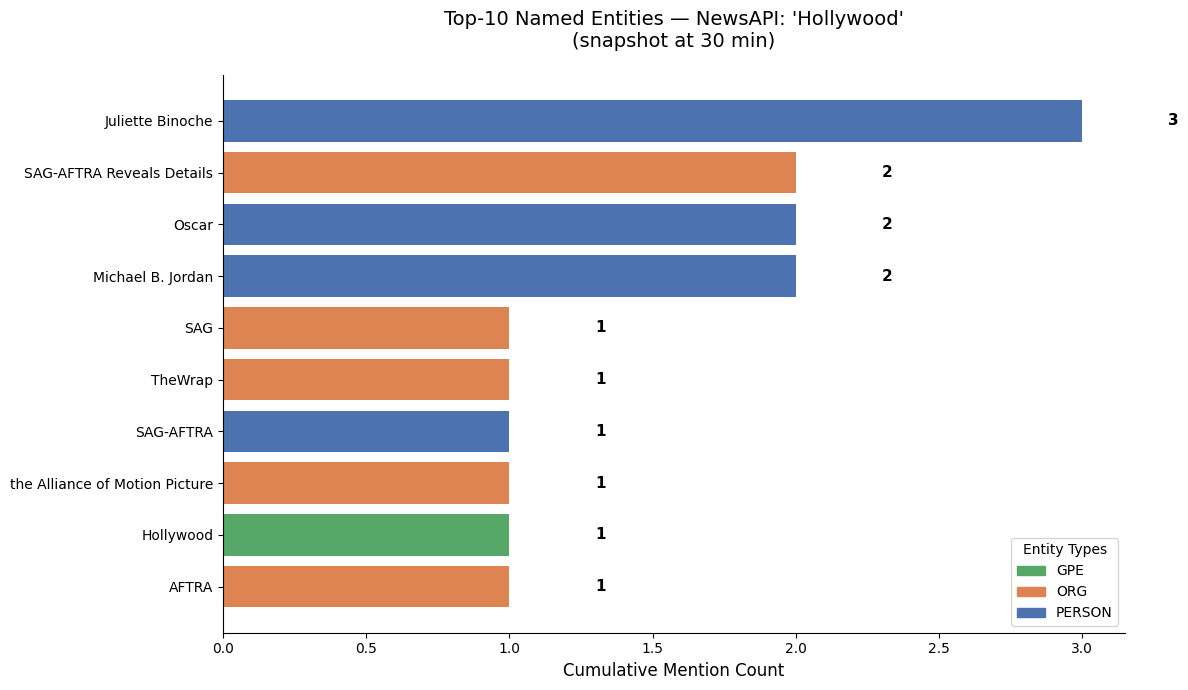

Waiting 15 min for next snapshot…



-- Snapshot @ 45 min --
[consumer] Reading from topic2...
Top 10 entities saved to top10_entities.json
✓ Chart saved to top10_entities_45min.png


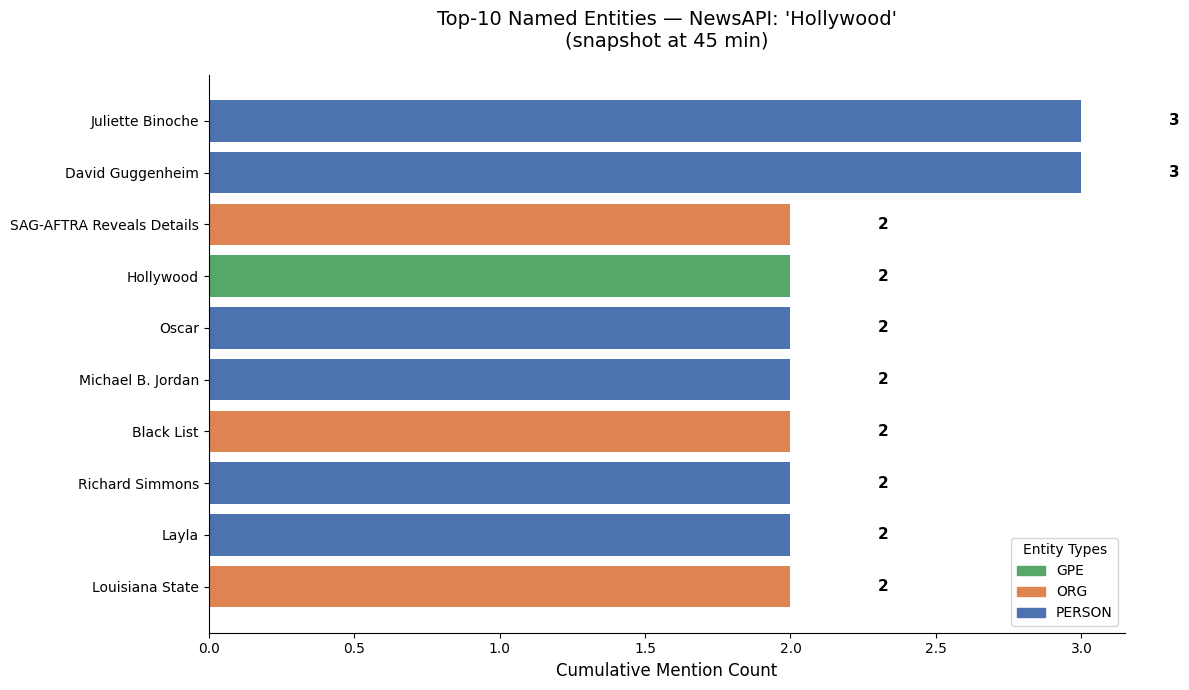

Waiting 15 min for next snapshot…



-- Snapshot @ 60 min --
[consumer] Reading from topic2...
Top 10 entities saved to top10_entities.json
✓ Chart saved to top10_entities_60min.png


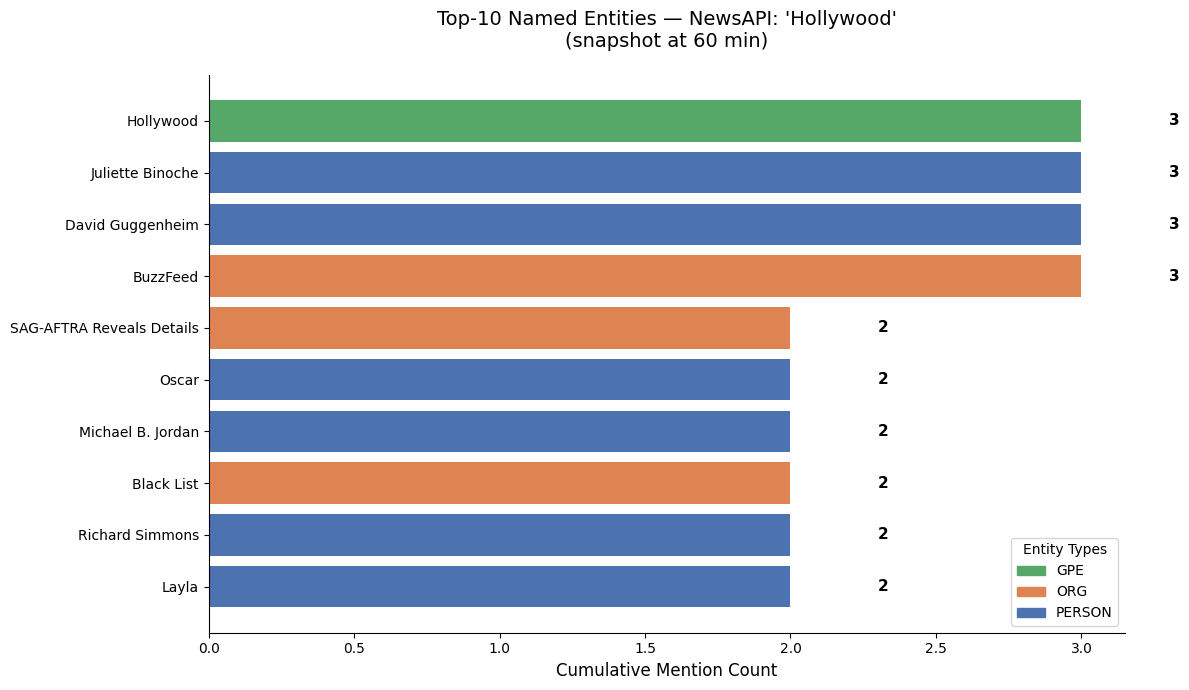

In [ ]:
import json, time
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from kafka import KafkaConsumer

# Color palette by entity type — use this in your bar chart
PALETTE = {
    "PERSON":  "#4C72B0",
    "ORG":     "#DD8452",
    "GPE":     "#55A868",
    "LOC":     "#C44E52",
    "NORP":    "#8172B2",
    "EVENT":   "#937860",
    "PRODUCT": "#DA8BC3",
    "LAW":     "#8C8C8C",
}


def fetch_top10(bootstrap_servers="localhost:9092", topic="topic2",
                save_path="top10_entities.json"):
  consumer = KafkaConsumer(
    topic,
    bootstrap_servers=bootstrap_servers,
    auto_offset_reset="earliest",
    consumer_timeout_ms=8000,
    value_deserializer = lambda v: json.loads(v.decode("utf-8")))

  latest_counts = {}

  print(f"[consumer] Reading from {topic}...")
  for message in consumer:
    data = message.value
    entity_name = data.get("entity")
    if entity_name:
      latest_counts[entity_name] = data
  consumer.close()
  top10 = sorted(latest_counts.values(), key=lambda x: x['count'], reverse=True)[:10]
  if top10 and save_path:
    with open(save_path, "w") as f:
      json.dump(top10, f, indent=4)
    print(f"Top 10 entities saved to {save_path}")

  return top10



def plot_top10(top10, interval_label, query_label, save_path=None):
  if not top10:
    print("No entities found yet. Skipping plot.")
    return

  entities = [item['entity'] for item in reversed (top10)]
  counts = [item['count'] for item in reversed (top10)]
  labels = [item['label'] for item in reversed (top10)]

  colors = [PALETTE.get(label, "#64B5CD") for label in labels]

  plt.figure(figsize = (12,7))
  bars = plt.barh(entities, counts, color=colors)

  for bar in bars:
    width = bar.get_width()
    plt.text(width + 0.3, bar.get_y() + bar.get_height()/2,
             f'{int(width)}', va="center", fontsize=11, fontweight='bold')

  plt.xlabel("Cumulative Mention Count", fontsize=12)
  plt.title(f"Top-10 Named Entities — NewsAPI: {query_label!r}\n(snapshot at {interval_label})",
              fontsize=14, pad=20)


  used_labels = sorted(list(set(labels)))
  patches = [mpatches.Patch(color=PALETTE.get(l, "#64B5CD"), label=l) for l in used_labels]
  plt.legend(handles=patches, title="Entity Types", loc='lower right', frameon=True)


  plt.gca().spines['top'].set_visible(False)
  plt.gca().spines['right'].set_visible(False)
  plt.tight_layout()


  if save_path:
    plt.savefig(save_path, dpi=150, bbox_inches="tight")
    print(f"✓ Chart saved to {save_path}")

  plt.show()
  plt.close()


INTERVALS = [15, 30, 45, 60]


for i, minutes in enumerate(INTERVALS):
    label = f"{minutes} min"
    save  = f"top10_entities_{minutes}min.png"

    # Wait 15 minutes BEFORE taking the snapshot
    wait_sec = 15 * 60
    print(f"Waiting 15 min for the {label} snapshot…")
    time.sleep(wait_sec)

    # Execute snapshot after the wait
    print(f"\n-- Snapshot @ {label} --")
    top10 = fetch_top10()   # also auto-saves to top10_entities.json
    plot_top10(top10, label, query_label=NEWS_QUERY, save_path=save)

---
## Section 3.5 — LLM Entity Enrichment


> **Free Groq key (no credit card):** https://console.groq.com  



In [ ]:
import os

os.environ["GROQ_API_KEY"] = "YOUR_GROQ_KEY_HERE"   # ← paste your key

if os.environ["GROQ_API_KEY"] == "YOUR_GROQ_KEY_HERE":
    raise ValueError("Please replace YOUR_GROQ_KEY_HERE with your actual Groq key!")

print("✓ Groq key configured")


✓ Groq key configured


In [ ]:
import json, os, time
from groq import Groq


def load_entities(path):
  if not os.path.exists(path):
    raise FileNotFoundError(f"File not found: {path}")

  with open(path, "r") as f:
    data = json.load(f)

  if not data:
    raise ValueError(f"Empty file: {path}")

  return data


def build_prompt(entity_name, entity_label, query):
  return(f"You are a professional news analyst. "
        f"In exactly 1-2 sentences, explain why the {entity_label} named '{entity_name}' "
        f"is prominently appearing in recent news regarding '{query}'. "
        f"Focus exclusively on current events and recent developments.")


def enrich_entity(client, entity_name, entity_label, query):
  response = client.chat.completions.create(model="llama-3.1-8b-instant",
                                            messages=[{"role": "user","content": build_prompt(entity_name, entity_label, query)}],
                                            max_tokens=200,
                                            temperature=0.7)
  return response.choices[0].message.content.strip()


# ── Configure Groq ────────────────────────────────────────────────────────────
client = Groq(api_key=os.environ["GROQ_API_KEY"])

# ── Load entities ─────────────────────────────────────────────────────────────
entities = load_entities("top10_entities.json")
print(f"Loaded {len(entities)} entities\n")

# ── Enrich each entity ────────────────────────────────────────────────────────
results = []
for i, item in enumerate(entities):
    name  = item["entity"]
    label = item["label"]
    count = item["count"]
    print(f"  Querying: {name!r} [{label}] (count={count})...")
    try:
        summary = enrich_entity(client, name, label, NEWS_QUERY)
    except Exception as e:
        summary = f"[ERROR: {e}]"
    results.append({**item, "summary": summary})
    print(f"    → {summary[:120]}\n")
    if i < len(entities) - 1:
        time.sleep(2)

# ── Write Markdown report ─────────────────────────────────────────────────────
with open("entity_enrichment.md", "w") as f:
    f.write(f"# Entity Enrichment Report\n")
    f.write(f"**NewsAPI query:** `{NEWS_QUERY}`  \n")
    f.write(f"**Model:** `llama-3.1-8b-instant (Groq)`\n\n---\n\n")
    for r in results:
        f.write(f"## {r['entity']} `[{r['label']}]`\n")
        f.write(f"**Mention count:** {r['count']}  \n\n")
        f.write(f"{r['summary']}\n\n---\n\n")

print("✓ Enrichment report saved → entity_enrichment.md")

Loaded 10 entities

  Querying: 'Hollywood' [GPE] (count=3)...
    → The Global Peace Elite (GPE) named 'Hollywood' has been prominently featured in recent news regarding Hollywood due to i

  Querying: 'Juliette Binoche' [PERSON] (count=3)...
    → Juliette Binoche is prominently appearing in recent news regarding Hollywood due to her recent starring role in the high

  Querying: 'David Guggenheim' [PERSON] (count=3)...
    → I couldn't find any information on a prominent person named David Guggenheim related to recent news in Hollywood. Howeve

  Querying: 'BuzzFeed' [ORG] (count=3)...
    → BuzzFeed is prominently appearing in recent news regarding Hollywood due to its recent acquisition by the media conglome

  Querying: 'SAG-AFTRA Reveals Details' [ORG] (count=2)...
    → SAG-AFTRA Reveals Details is prominently appearing in recent news regarding 'Hollywood' due to the union's ongoing negot

  Querying: 'Oscar' [PERSON] (count=2)...
    → Oscar Isaac is prominently appearing in re

In [ ]:
# ── Display the enrichment report inline ─────────────────────────────────────
from IPython.display import Markdown, display

with open("entity_enrichment.md") as f:
    display(Markdown(f.read()))


# Entity Enrichment Report
**NewsAPI query:** `Hollywood`  
**Model:** `llama-3.1-8b-instant (Groq)`

---

## Hollywood `[GPE]`
**Mention count:** 3  

The Global Peace Elite (GPE) named 'Hollywood' has been prominently featured in recent news regarding Hollywood due to its involvement in promoting peace and understanding through the arts, specifically through collaborations with A-list celebrities to raise awareness about international conflicts and humanitarian crises.

---

## Juliette Binoche `[PERSON]`
**Mention count:** 3  

Juliette Binoche is prominently appearing in recent news regarding Hollywood due to her recent starring role in the highly anticipated film "Three Hours," which premiered at the 2023 Toronto International Film Festival and has garnered significant attention for its thought-provoking plot and her critically acclaimed performance. Her involvement in this project has sparked discussions about her enduring presence in the film industry and her ability to captivate audiences with her nuanced acting style.

---

## David Guggenheim `[PERSON]`
**Mention count:** 3  

I couldn't find any information on a prominent person named David Guggenheim related to recent news in Hollywood. However, I did find a documentary filmmaker named David Guggenheim, who recently made headlines with his documentary "The China Hustle: Inside China's Economic Miracle," but I couldn't find any connection between him and current Hollywood news.

---

## BuzzFeed `[ORG]`
**Mention count:** 3  

BuzzFeed is prominently appearing in recent news regarding Hollywood due to its recent acquisition by the media conglomerate, Paramount Global, which has sparked controversy and raised questions about the future of the digital media landscape in the entertainment industry. This development has also led to speculation about potential changes to the company's editorial direction and the role it will play in shaping the narrative around Hollywood.

---

## SAG-AFTRA Reveals Details `[ORG]`
**Mention count:** 2  

SAG-AFTRA Reveals Details is prominently appearing in recent news regarding 'Hollywood' due to the union's ongoing negotiations for a new contract with major film and television studios, which are expected to significantly impact the working conditions, pay, and benefits of actors and other industry professionals. The negotiations are gaining attention as the current contract is set to expire in June 2026, and the union is pushing for major concessions from the studios, which could have far-reaching implications for the entertainment industry.

---

## Oscar `[PERSON]`
**Mention count:** 2  

Oscar Isaac is prominently appearing in recent news regarding Hollywood due to his starring role in the highly anticipated film 'Moon Knight', which has received widespread critical acclaim and attention ahead of its streaming release on Disney+.

---

## Michael B. Jordan `[PERSON]`
**Mention count:** 2  

Michael B. Jordan is prominently appearing in recent news regarding Hollywood due to his role as the director of the highly anticipated film "Creed III," which is set to release in March 2023 and promises to be a significant box office hit. His involvement in this project, in addition to his previous success with the "Creed" and "Black Panther" franchises, has sparked widespread interest in the film industry.

---

## Black List `[ORG]`
**Mention count:** 2  

The "Black List" is prominently appearing in recent Hollywood news due to its annual publication of the most buzzed-about unproduced screenplays, which often serve as a barometer for the industry's emerging talent and trends. This year's list, released in December 2022, features several high-profile writers and projects that are generating significant buzz and sparking conversations about the future of Hollywood storytelling.

---

## Richard Simmons `[PERSON]`
**Mention count:** 2  

Richard Simmons, the fitness guru and pop culture icon, is currently at the center of a high-profile defamation lawsuit against a celebrity blogger, with recent developments in the case sparking renewed interest in his personal life and career. The case has also led to a renewed focus on Simmons' long-standing feud with a former friend, with many outlets revisiting their past interactions and conflicts.

---

## Layla `[PERSON]`
**Mention count:** 2  

I'm not aware of any recent information regarding a person named Layla associated with Hollywood. Could you provide more context or clarify which specific event or issue you are referring to?

---



---
## Section 4 — Cleanup
Stop all background processes.


In [ ]:
import signal

for proc, name in [(producer_proc, "NewsAPI producer"), (spark_proc, "Spark streaming")]:
    try:
        proc.send_signal(signal.SIGTERM)
        proc.wait(timeout=10)
        print(f"✓ {name} stopped")
    except Exception as e:
        print(f"  {name}: {e}")

KAFKA_DIR = "kafka_2.13-3.7.1"
!{KAFKA_DIR}/bin/kafka-server-stop.sh
print("✓ Kafka broker stopped")


✓ NewsAPI producer stopped
✓ Spark streaming stopped
✓ Kafka broker stopped


In [ ]:
print("=== producer.log (last 15 lines) ===")
!tail -n 15 producer.log

print("\n=== spark_streaming.log (last 20 lines) ===")
!tail -n 20 spark_streaming.log


=== producer.log (last 15 lines) ===

=== spark_streaming.log (last 20 lines) ===
  SAG-AFTRA Reveals Details                [ORG     ] count=2
  Michael B. Jordan                        [PERSON  ] count=2
  American                                 [NORP    ] count=2
  Richard Simmons                          [PERSON  ] count=2
  Lane Kiffin's                            [PERSON  ] count=2
  Shannon Elizabeth                        [PERSON  ] count=2
  Oscar                                    [PERSON  ] count=2
26/05/13 02:19:13 WARN HDFSBackedStateStoreProvider: The state for version 7 doesn't exist in loadedMaps. Reading snapshot file and delta files if needed...Note that this is normal for the first batch of starting query.

[batch 7] Top-10 entities (2026-05-13T02:19:12.930597+00:00)
  David Guggenheim                         [PERSON  ] count=3
  BuzzFeed                                 [ORG     ] count=3
  Hollywood                                [GPE     ] count=3
  Juliette Binoc